In [1]:
from model.lagllama.utils.lagllama_loader import (load_llama,
                                                  get_superposed_llama_representation,
                                                  LatentLlamaLoader)
import config
config.configure_global_paths()
import numpy as np
from model.M_mahala.movingmahala import MovingMahalanobis
from utils.utils import create_windows, normalise, score_windows
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

/home/onyxia/work/.venv/lib/python3.12/site-packages/gluonts/json.py:101: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [2]:
period = 32 # taille de la séquence
path_to_file = "/home/onyxia/work/moving_mahalanobis/data/NAB_anomaly/ec2_cpu_utilization_ac20cd.csv"
df = pd.read_csv(path_to_file)
X = df["value"].to_numpy()
y = df["label"].to_numpy()
X = create_windows(X.flatten(), seq_len=period, stride=period) # découper en fenetre
y = create_windows(y.flatten(), seq_len=period, stride=period)
model, dataset = load_llama(X, context_length=period, stride=period,
                            ckpt_path="/home/onyxia/work/moving_mahalanobis/lag-llama.ckpt")

LatentLoader = LatentLlamaLoader(dataset, get_superposed_llama_representation, model, device="cpu") # créer le loader pour le model

In [3]:
mahala = MovingMahalanobis(y, LatentLoader, model_name="LagLlama", X=X, seq_len=period)
out = mahala.fit(print_results=False, thresh=8, mode_auto=True, windows=True, verbose=True, selection="coreset", n_channels=8)
for key in out.keys():
    print(key, ":", out[key])


100%|██████████| 125/125 [00:03<00:00, 34.05it/s]

Accuracy : 0.9829059829059829
F1 : 0.5
Precision : 0.3333333333333333
Recall : 1.0
Roc_Auc : 0.9827586206896551
AUPr : 0.3333333333333333
FPR@95% : 0.017241379310344827
n_anomaly : 1
n_data : 117
model : LagLlama


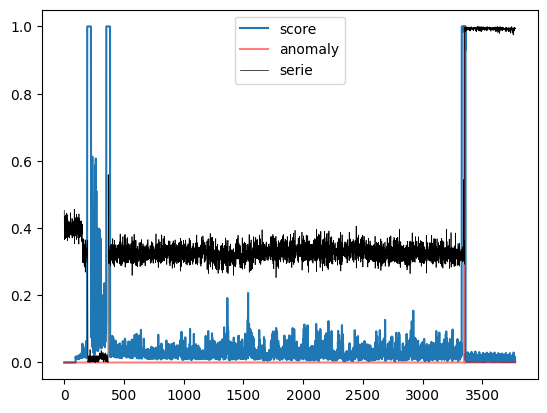

In [4]:
label_w, score_w = score_windows(mahala.labels, mahala.score, seq_len=32)

plt.plot(normalise(np.clip(mahala.score, None, 40)), label="score")
plt.plot(mahala.labels, alpha=0.5, c="r", label="anomaly")
plt.plot(normalise(X.flatten()[-len(mahala.score):]), linewidth=0.5, alpha=1, c="black", label="serie")
plt.legend()
plt.show()